In [1]:
!pip install pandas scikit-learn joblib gensim transformers torch python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re, json, joblib, torch
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import FastText
from transformers import AutoTokenizer, AutoModel
import Levenshtein
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

In [3]:
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving PR_PO_dataset_full_with_categories_augmented.csv to PR_PO_dataset_full_with_categories_augmented.csv


In [4]:
PR_COL = "PR_General_Desc"
PO_COL = "PO_General_Desc"
LABEL_COL = "Label"

In [5]:
df = df.dropna(subset=[PR_COL, PO_COL, LABEL_COL])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["pr_clean"] = df[PR_COL].apply(clean_text)
df["po_clean"] = df[PO_COL].apply(clean_text)
df["combined"] = df["pr_clean"] + " [SEP] " + df["po_clean"]
y = df[LABEL_COL].astype(str)

print("Total records:", len(df))
print(y.value_counts())
df.head()

Total records: 80
Label
OK             42
Discrepancy    38
Name: count, dtype: int64


,Category,Label,PR_General Description and Objective of the Project to be Procured,PR_Type of the Project to be Procured,PR_Quantity and Size of the Project to be Procured,PR_Recommended Mode of Procurement,PR_Pre-Procurement Conference Applicable (Yes/No),PR_Start of Procurement Activity,PR_End of Procurement Activity,PR_Expected Delivery/Implementation Period,...,PO_Expected Delivery/Implementation Period,PO_Source of Funds,PO_Estimated Budget Allocation (Php),PO_Attached Supporting Documents,PO_Remarks,PR_General_Desc,PO_General_Desc,pr_clean,po_clean,combined
0,DBM,OK,Procurement of Office Supplies,Goods,2 btls. Ink T663 magentaaa,Agency to Agency,No,January 2026,December 2026,Jan. - Dec. 2026,...,Jan. - Dec. 2026,GF,80000,NaN,NaN,Procurement of Office Supplies | Goods | 2 btl...,Procurement of Office Supplies | Goods | 2 btl...,procurement of office supplies goods 2 btls in...,procurement of office supplies goods 2 btls in...,procurement of office supplies goods 2 btls in...
1,DBM,OK,Procurement of Office Supplies,Goods,2 btls. Ink T664 yellow,Agency to Agency,No,January 2026,December 2026,Jan. - Dec. 2026,...,Jan. - Dec. 2026,GF,0,NaN,NaN,Procurement of Office Supplies | Goods | 2 btl...,Procurement of Office Supplies | Goods | 2 btl...,procurement of office supplies goods 2 btls in...,procurement of office supplies goods 2 btls in...,procurement of office supplies goods 2 btls in...
2,DBM,Discrepancy,Procurement of Office Supplies,GoodsD,2 rolls Masking Tape 2 inchesss,Agency to Agency,No,January 2026,December 2026,Jan. - Dec. 2026,...,Jan. - Dec. 2026,GF,0,NaN,NaN,Procurement of Office Supplies | GoodsD | 2 ro...,Procurement of Office Supplies | GoodsD update...,procurement of office supplies goodsd 2 rolls ...,procurement of office supplies goodsd updated ...,procurement of office supplies goodsd 2 rolls ...
3,DBM,Discrepancy,Procurement of Office Supplies,Goods,24 pcs. Ballpen LV 0.5 blue and black,Agency to Agency,No,January 2026,December 2026,Jan. - Dec. 2026,...,Jan. - Dec. 2026 updated,GF updated,0,NaN,NaN,Procurement of Office Supplies | Goods | 24 pc...,Procurement of Office Supplies | Goods | 24 pc...,procurement of office supplies goods 24 pcs ba...,procurement of office supplies goods 24 pcs ba...,procurement of office supplies goods 24 pcs ba...
4,DBM,Discrepancy,Procurement of Office Supplies,Goods,30 btls. Ink 003 black,Agency to Agency,No,January 2026,December 2026,Jan. - Dec. 2026,...,Jan. - Dec. 2026,GF updated,0,NaN,NaN,Procurement of Office Supplies | Goods | 30 bt...,Procurement of Office Supplies | Goods | 30 bt...,procurement of office supplies goods 30 btls i...,procurement of office supplies goods 30 btls i...,procurement of office supplies goods 30 btls i...


In [6]:
def cosine_similarity_score(pr_text, po_text, vectorizer):
    pr_vec = vectorizer.transform([pr_text])
    po_vec = vectorizer.transform([po_text])
    return sk_cosine(pr_vec, po_vec)[0][0]

def levenshtein_score(pr_text, po_text):
    return Levenshtein.ratio(str(pr_text), str(po_text))

def jaccard_similarity(pr_text, po_text):
    stopwords = {"and", "or", "of", "the", "to", "for", "with", "a", "an", "in"}
    pr_tokens = set(str(pr_text).lower().split()) - stopwords
    po_tokens = set(str(po_text).lower().split()) - stopwords
    intersection = pr_tokens.intersection(po_tokens)
    union = pr_tokens.union(po_tokens)
    if not union:
        return 1.0
    return len(intersection) / len(union)

In [7]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000)
X_tfidf = tfidf_vectorizer.fit_transform(df["combined"])

In [8]:
sentences = [text.split() for text in df["combined"]]
fasttext_model = FastText(
    sentences=sentences,
    vector_size=150,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=30
)

def fasttext_vector(text):
    words = clean_text(text).split()
    vectors = [fasttext_model.wv[word] for word in words if word in fasttext_model.wv]
    if not vectors:
        return np.zeros(fasttext_model.vector_size)
    return np.mean(vectors, axis=0)

X_fasttext = np.vstack([fasttext_vector(text) for text in df["combined"]])

In [9]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-uncased")
distilbert_model.eval()

def distilbert_vector(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    with torch.no_grad():
        outputs = distilbert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

X_distilbert = np.vstack([distilbert_vector(text) for text in df["combined"]])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
cosine_scores = [cosine_similarity_score(df['PR_General_Desc'][i], df['PO_General_Desc'][i], tfidf_vectorizer)
                 for i in range(len(df))]

lev_scores = [levenshtein_score(df['PR_General_Desc'][i], df['PO_General_Desc'][i])
              for i in range(len(df))]

jaccard_scores = [jaccard_similarity(df['PR_General_Desc'][i], df['PO_General_Desc'][i])
                  for i in range(len(df))]

In [11]:
num_diff_list = []
for i in range(len(df)):
    num_diff = []
    for col in df.columns:
        if col.startswith('PR_') and col != PR_COL:
            pr_val = df.loc[i, col]
            po_val = df.loc[i, col.replace('PR_', 'PO_')]
            try:
                pr_num = float(pr_val)
                po_num = float(po_val)
                num_diff.append(abs(pr_num - po_num))
            except:
                continue
    num_diff_list.append(num_diff if num_diff else [0])

In [14]:
tfidf_scores = [cosine_similarity_score(df['PR_General_Desc'][i], df['PO_General_Desc'][i], tfidf_vectorizer)
                for i in range(len(df))]

In [16]:
lev_scores = [levenshtein_score(df['PR_General_Desc'][i], df['PO_General_Desc'][i])
              for i in range(len(df))]

# If using DistilBERT similarity
distil_scores = [X_distilbert[i].mean() for i in range(len(df))]

# Jaccard similarity
jaccard_scores = [jaccard_similarity(df['PR_General_Desc'][i], df['PO_General_Desc'][i])
                  for i in range(len(df))]

In [18]:

max_len = max(len(x) for x in num_diff_list)
num_diff_array = np.array([x + [0]*(max_len-len(x)) for x in num_diff_list])


X = np.hstack([
    X_tfidf.toarray(),
    X_fasttext,
    X_distilbert,
    np.array(cosine_scores).reshape(-1,1),
    np.array(lev_scores).reshape(-1,1),
    np.array(jaccard_scores).reshape(-1,1),
    num_diff_array
])

In [19]:
def train_and_evaluate(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=3000, class_weight="balanced")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    result = {
        "NLP Approach": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Classifier": clf
    }
    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return result

In [20]:
results = [
    train_and_evaluate("TF-IDF", X_tfidf.toarray(), y),
    train_and_evaluate("FastText", X_fasttext, y),
    train_and_evaluate("DistilBERT", X_distilbert, y)
]

results_df = pd.DataFrame([
    {
        "NLP Approach": r["NLP Approach"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-Score": r["F1-Score"]
    }
    for r in results
])
results_df.sort_values("F1-Score", ascending=False)


TF-IDF
              precision    recall  f1-score   support

 Discrepancy       0.17      0.12      0.14         8
          OK       0.30      0.38      0.33         8

    accuracy                           0.25        16
   macro avg       0.23      0.25      0.24        16
weighted avg       0.23      0.25      0.24        16

Confusion Matrix:
[[1 7]
 [5 3]]

FastText
              precision    recall  f1-score   support

 Discrepancy       0.20      0.12      0.15         8
          OK       0.36      0.50      0.42         8

    accuracy                           0.31        16
   macro avg       0.28      0.31      0.29        16
weighted avg       0.28      0.31      0.29        16

Confusion Matrix:
[[1 7]
 [4 4]]

DistilBERT
              precision    recall  f1-score   support

 Discrepancy       0.20      0.12      0.15         8
          OK       0.36      0.50      0.42         8

    accuracy                           0.31        16
   macro avg       0.28      0.3

,NLP Approach,Accuracy,Precision,Recall,F1-Score
1,FastText,0.3125,0.281818,0.3125,0.287449
2,DistilBERT,0.3125,0.281818,0.3125,0.287449
0,TF-IDF,0.2500,0.233333,0.2500,0.238095


In [21]:
best = max(results, key=lambda x: x["F1-Score"])
best_method = best["NLP Approach"]
best_classifier = best["Classifier"]

print("BEST NLP APPROACH:", best_method)
print("Accuracy:", best["Accuracy"])
print("Precision:", best["Precision"])
print("Recall:", best["Recall"])
print("F1-Score:", best["F1-Score"])

BEST NLP APPROACH: FastText
Accuracy: 0.3125
Precision: 0.28181818181818186
Recall: 0.3125
F1-Score: 0.2874493927125506


In [22]:
joblib.dump(best_classifier, "/content/nlp_discrepancy_model.pkl")

method_info = {
    "method": best_method,
    "classifier": "LogisticRegression",
    "description": "Best NLP approach selected from TF-IDF, FastText, and DistilBERT based on F1-score."
}

with open("/content/nlp_method.json", "w") as f:
    json.dump(method_info, f, indent=4)

if best_method == "TF-IDF":
    joblib.dump(tfidf_vectorizer, "/content/tfidf_vectorizer.pkl")
elif best_method == "FastText":
    fasttext_model.save("/content/fasttext_model.model")
elif best_method == "DistilBERT":
    pass

In [23]:
files.download("/content/nlp_discrepancy_model.pkl")
files.download("/content/nlp_method.json")

if best_method == "TF-IDF":
    files.download("/content/tfidf_vectorizer.pkl")
elif best_method == "FastText":
    files.download("/content/fasttext_model.model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import os

# Show all FastText files in current session
for f in os.listdir('/content'):
    if 'fasttext' in f.lower():
        print(f)

fasttext_model.model
fasttext_model.model.wv.vectors_ngrams.npy


In [27]:
import numpy as np
import json


vocab = list(fasttext_model.wv.index_to_key)
with open("/content/fasttext_vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f)


vectors = np.array([fasttext_model.wv[w] for w in vocab])
np.save("/content/fasttext_vectors.npy", vectors)

In [28]:
from google.colab import files
files.download("/content/fasttext_vocab.json")
files.download("/content/fasttext_vectors.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
results_df.to_csv("training_results.csv", index=False)

In [49]:
def train_and_evaluate(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=3000, class_weight="balanced")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    result = {
        "NLP Approach": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Classifier": clf,
        "y_test": y_test,
        "y_pred": y_pred
    }

    return result

In [57]:
def train_and_evaluate(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = LogisticRegression(max_iter=3000, class_weight="balanced")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    result = {
        "NLP Approach": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Classifier": clf,
        "y_test": y_test,
        "y_pred": y_pred
    }

    return result

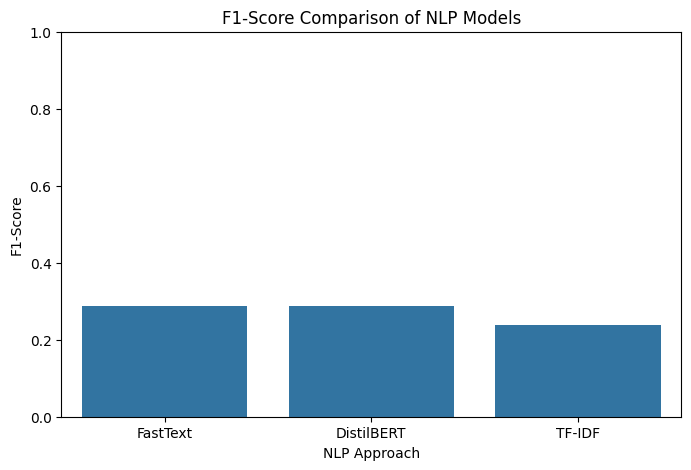

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns


metrics_df = pd.DataFrame([
    {
        "NLP Approach": r["NLP Approach"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-Score": r["F1-Score"]
    }
    for r in results
])

metrics_df = metrics_df.sort_values("F1-Score", ascending=False)
metrics_df


plt.figure(figsize=(8,5))
sns.barplot(x="NLP Approach", y="F1-Score", data=metrics_df)
plt.title("F1-Score Comparison of NLP Models")
plt.ylim(0,1)
plt.show()

In [59]:

metrics_df[["NLP Approach", "Accuracy", "Precision", "Recall", "F1-Score"]]

,NLP Approach,Accuracy,Precision,Recall,F1-Score
1,FastText,0.3125,0.281818,0.3125,0.287449
2,DistilBERT,0.3125,0.281818,0.3125,0.287449
0,TF-IDF,0.2500,0.233333,0.2500,0.238095


In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for r in results:
    y_test = r["y_test"]
    y_pred = r["y_pred"]
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {r['NLP Approach']}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

KeyError: 'y_test'